In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'kafein': [0.8, 0.9, 1.0, 1.1, 1.2, 0.85, 0.95, 1.05, 1.15, 0.7,
               2.0, 2.2, 2.5, 2.1, 2.3, 2.6, 2.4, 2.8, 2.7, 3.0,
               1.5, 1.6, 1.4, 1.7, 1.8, 2.1, 1.9, 2.2, 2.0, 2.5],
    'keasaman': [7, 8, 7, 6, 8, 7, 6, 7, 8, 7,
                 3, 2, 4, 3, 2, 4, 3, 2, 1, 2,
                 5, 4, 5, 4, 3, 4, 5, 3, 4, 2],
    'jenis_kopi': [0,0,0,0,0,0,0,0,0,0, 1,1,1,1,1,1,1,1,1,1, 1,1,1,1,1,1,1,1,1,1]

}

df = pd.DataFrame(data)

x = df[['kafein','keasaman']]
y = df['jenis_kopi']


scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)


model = KNeighborsClassifier(n_neighbors=3)
model.fit(x_train, y_train)


y_pred = model.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


Kopi Arabika (Label 0): Memiliki karakteristik kadar kafein rendah (sekitar 0.7 - 1.2) dan tingkat keasaman yang tinggi (6 - 8).

Kopi Robusta (Label 1): Memiliki karakteristik kadar kafein tinggi (sekitar 2.0 - 3.0) dan tingkat keasaman yang rendah (1 - 4).

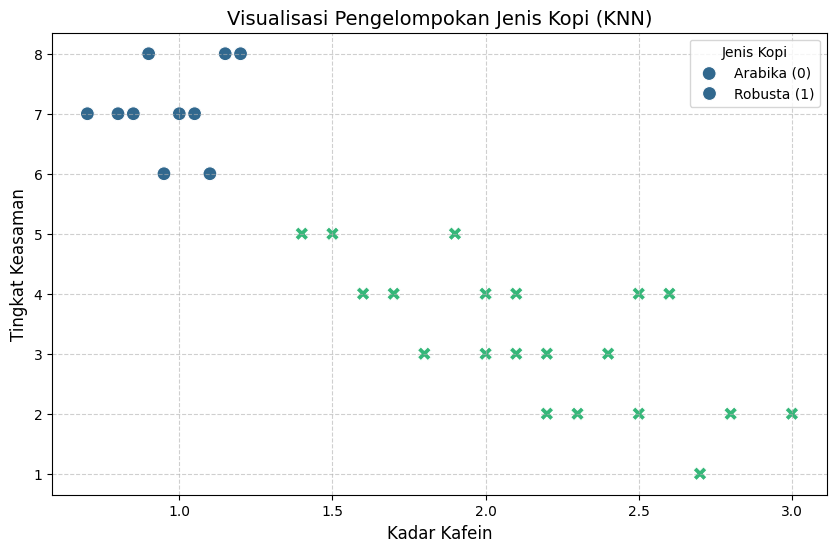

In [4]:
# Membuat DataFrame untuk visualisasi agar lebih mudah
df_vis = pd.DataFrame(data)
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='kafein',
    y='keasaman',
    hue='jenis_kopi',
    data=df_vis,
    palette='viridis',
    s=100,
    style='jenis_kopi'
)
plt.title('Visualisasi Pengelompokan Jenis Kopi (KNN)', fontsize=14)
plt.xlabel('Kadar Kafein', fontsize=12)
plt.ylabel('Tingkat Keasaman', fontsize=12)
plt.legend(title='Jenis Kopi', labels=['Arabika (0)', 'Robusta (1)'])
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Dalam grafik ini, bulat biru merepresentasikan training set yang digunakan untuk membentuk garis regresi, sedangkan 'X' hijau merepresentasikan testing set. Jarak antara 'X' hijau dengan garis merah prediksi menunjukkan tingkat error atau kesalahan prediksi dari model yang telah dibuat.